# Exercises XP – NumPy & Pandas

## Ce qu'on va apprendre
- Manipuler des matrices avec NumPy (déterminant, inverse)
- Calculer des statistiques descriptives (moyenne, médiane, écart-type)
- Manipuler des dates avec NumPy
- Faire de la sélection conditionnelle et de l'agrégation avec Pandas
- Comprendre la représentation des images en tableaux NumPy
- Réaliser un test d'hypothèse simple
- Comparer des tableaux élément par élément
- Manipuler des séries temporelles
- Convertir entre NumPy et Pandas
- Visualiser des données avec Matplotlib


## Exercise 1 – Matrix Operations

On travaille avec une matrice carrée 3x3.

- **Déterminant** : une valeur scalaire calculée à partir des éléments d'une matrice carrée. Il indique notamment si la matrice est inversible (déterminant non nul).
- **Inverse d'une matrice** : la matrice `A⁻¹` telle que `A · A⁻¹ = I` (matrice identité). Elle n'existe que si le déterminant est non nul, et sert notamment à résoudre des systèmes d'équations linéaires.

In [1]:
import numpy as np

# Matrice 3x3
A = np.array([
    [2, 1, 1],
    [1, 3, 2],
    [1, 0, 0]
])

print("Matrice A :")
print(A)

# Déterminant
det_A = np.linalg.det(A)
print(f"\nDéterminant de A : {det_A:.2f}")

# Inverse (possible car det_A != 0)
if det_A != 0:
    inv_A = np.linalg.inv(A)
    print("\nInverse de A :")
    print(inv_A)

    # Vérification : A * A^-1 doit donner (proche de) l'identité
    print("\nVérification A @ A_inv (≈ identité) :")
    print(np.round(A @ inv_A, 6))
else:
    print("La matrice n'est pas inversible (déterminant = 0).")

Matrice A :
[[2 1 1]
 [1 3 2]
 [1 0 0]]

Déterminant de A : -1.00

Inverse de A :
[[ 0.  0.  1.]
 [-2.  1.  3.]
 [ 3. -1. -5.]]

Vérification A @ A_inv (≈ identité) :
[[ 1.  0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]


## Exercise 2 – Statistical Analysis

- **Mean (moyenne)** : valeur moyenne d'un ensemble de données.
- **Median (médiane)** : valeur centrale d'un ensemble de données trié.
- **Standard Deviation (écart-type)** : mesure de la dispersion des valeurs autour de la moyenne.

In [2]:
np.random.seed(42)

data = np.random.rand(50) * 100  # 50 nombres aléatoires entre 0 et 100

mean_val = np.mean(data)
median_val = np.median(data)
std_val = np.std(data)

print(f"Données (10 premières valeurs) : {np.round(data[:10], 2)}")
print(f"\nMoyenne     : {mean_val:.2f}")
print(f"Médiane     : {median_val:.2f}")
print(f"Écart-type  : {std_val:.2f}")

Données (10 premières valeurs) : [37.45 95.07 73.2  59.87 15.6  15.6   5.81 86.62 60.11 70.81]

Moyenne     : 44.59
Médiane     : 43.60
Écart-type  : 28.60


## Exercise 3 – Date Manipulation

On crée un tableau NumPy de dates pour le mois de janvier 2023, puis on convertit ces dates dans un autre format (`YYYY/MM/DD`).

In [3]:
# Dates de janvier 2023 (type datetime64[D])
january_dates = np.arange('2023-01-01', '2023-02-01', dtype='datetime64[D]')

print(f"Nombre de jours en janvier 2023 : {len(january_dates)}")
print("5 premières dates (format par défaut YYYY-MM-DD) :")
print(january_dates[:5])

# Conversion au format YYYY/MM/DD
formatted_dates = np.array([str(d).replace('-', '/') for d in january_dates])

print("\n5 premières dates (format YYYY/MM/DD) :")
print(formatted_dates[:5])

Nombre de jours en janvier 2023 : 31
5 premières dates (format par défaut YYYY-MM-DD) :
['2023-01-01' '2023-01-02' '2023-01-03' '2023-01-04' '2023-01-05']

5 premières dates (format YYYY/MM/DD) :
['2023/01/01' '2023/01/02' '2023/01/03' '2023/01/04' '2023/01/05']


## Exercise 4 – Data Manipulation with NumPy and Pandas

On crée un DataFrame de nombres aléatoires et on réalise :
- une **sélection conditionnelle** de données,
- des fonctions d'**agrégation** (somme, moyenne).

In [4]:
import pandas as pd

np.random.seed(42)

df = pd.DataFrame(
    np.random.randint(1, 100, size=(8, 4)),
    columns=['A', 'B', 'C', 'D']
)

print("DataFrame :")
print(df)

# Sélection conditionnelle : lignes où la colonne A > 50
print("\nLignes où A > 50 :")
print(df[df['A'] > 50])

# Agrégations
print("\nSomme par colonne :")
print(df.sum())

print("\nMoyenne par colonne :")
print(df.mean())

print(f"\nSomme totale du DataFrame : {df.values.sum()}")
print(f"Moyenne globale du DataFrame : {df.values.mean():.2f}")

DataFrame :
    A   B   C   D
0  52  93  15  72
1  61  21  83  87
2  75  75  88  24
3   3  22  53   2
4  88  30  38   2
5  64  60  21  33
6  76  58  22  89
7  49  91  59  42

Lignes où A > 50 :
    A   B   C   D
0  52  93  15  72
1  61  21  83  87
2  75  75  88  24
4  88  30  38   2
5  64  60  21  33
6  76  58  22  89

Somme par colonne :
A    468
B    450
C    379
D    351
dtype: int64

Moyenne par colonne :
A    58.500
B    56.250
C    47.375
D    43.875
dtype: float64

Somme totale du DataFrame : 1648
Moyenne globale du DataFrame : 51.50


## Exercise 5 – Image Representation

Une image est représentée par NumPy comme un tableau de pixels :
- une image en **niveaux de gris** est un tableau 2D `(hauteur, largeur)` où chaque valeur (0-255) représente l'intensité lumineuse d'un pixel (0 = noir, 255 = blanc).
- une image en **couleur** est un tableau 3D `(hauteur, largeur, 3)`, le dernier axe correspondant aux canaux Rouge, Vert, Bleu (RGB).

Ci-dessous, un exemple simple : une image en niveaux de gris de 5x5 pixels.

Tableau représentant l'image (niveaux de gris) :
[[  0  50 100 150 200]
 [ 50 100 150 200 250]
 [100 150 200 250 255]
 [150 200 250 255 200]
 [200 250 255 200 100]]

Forme du tableau : (5, 5)


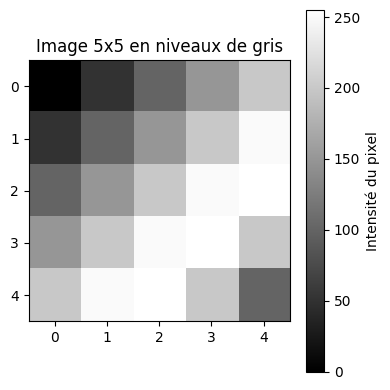

In [5]:
import matplotlib.pyplot as plt

# Image 5x5 en niveaux de gris (valeurs entre 0 et 255)
gray_image = np.array([
    [0,   50,  100, 150, 200],
    [50,  100, 150, 200, 250],
    [100, 150, 200, 250, 255],
    [150, 200, 250, 255, 200],
    [200, 250, 255, 200, 100]
])

print("Tableau représentant l'image (niveaux de gris) :")
print(gray_image)
print(f"\nForme du tableau : {gray_image.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(gray_image, cmap='gray', vmin=0, vmax=255)
plt.colorbar(label='Intensité du pixel')
plt.title('Image 5x5 en niveaux de gris')
plt.tight_layout()
plt.show()

## Exercise 6 – Basic Hypothesis Testing

On veut tester si le **programme de formation améliore la productivité** des employés.

**Hypothèses :**
- H0 (hypothèse nulle) : le programme n'a aucun effet, la différence moyenne de productivité est nulle.
- H1 (hypothèse alternative) : le programme améliore la productivité, la différence moyenne est positive.

On compare les scores avant/après avec un test t apparié (paired t-test), calculé ici "à la main" avec NumPy.

In [6]:
np.random.seed(42)

# Productivité avant/après le programme de formation
productivity_before = np.random.normal(loc=50, scale=10, size=30)
productivity_after = productivity_before + np.random.normal(loc=5, scale=3, size=30)

# Différences pairées
differences = productivity_after - productivity_before

mean_diff = np.mean(differences)
std_diff = np.std(differences, ddof=1)
n = len(differences)

# Statistique du test t apparié
se = std_diff / np.sqrt(n)
t_stat = mean_diff / se

print(f"Productivité moyenne avant  : {productivity_before.mean():.2f}")
print(f"Productivité moyenne après  : {productivity_after.mean():.2f}")
print(f"Différence moyenne          : {mean_diff:.2f}")
print(f"Écart-type des différences  : {std_diff:.2f}")
print(f"Statistique t                : {t_stat:.2f}")

# Seuil critique approximatif pour un test unilatéral à 95% (df=29) : ~1.699
critical_value = 1.699
if t_stat > critical_value:
    print("\nConclusion : on rejette H0 -> le programme de formation améliore significativement la productivité.")
else:
    print("\nConclusion : on ne peut pas rejeter H0 -> pas de preuve suffisante d'un effet significatif.")

Productivité moyenne avant  : 48.12
Productivité moyenne après  : 52.76
Différence moyenne          : 4.64
Écart-type des différences  : 2.79
Statistique t                : 9.09

Conclusion : on rejette H0 -> le programme de formation améliore significativement la productivité.


## Exercise 7 – Complex Array Comparison

On compare deux tableaux élément par élément pour savoir lesquels sont plus grands dans le premier tableau.

In [7]:
array1 = np.array([10, 25, 3, 47, 8, 60])
array2 = np.array([15, 20, 5, 40, 8, 55])

comparison = array1 > array2

print(f"Tableau 1 : {array1}")
print(f"Tableau 2 : {array2}")
print(f"\nÉléments de array1 > array2 (tableau booléen) :")
print(comparison)

print(f"\nValeurs de array1 supérieures à array2 : {array1[comparison]}")

Tableau 1 : [10 25  3 47  8 60]
Tableau 2 : [15 20  5 40  8 55]

Éléments de array1 > array2 (tableau booléen) :
[False  True False  True False  True]

Valeurs de array1 supérieures à array2 : [25 47 60]


## Exercise 8 – Time Series Data Manipulation

On génère une série temporelle pour l'année 2023 (fréquence journalière) et on découpe cette série par trimestre.

In [8]:
dates_2023 = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

time_series = pd.Series(np.random.rand(len(dates_2023)) * 100, index=dates_2023)

print(f"Nombre total de jours en 2023 : {len(time_series)}")
print("\nAperçu de la série temporelle :")
print(time_series.head())

# Découpage par trimestre
q1 = time_series['2023-01':'2023-03']
q2 = time_series['2023-04':'2023-06']
q3 = time_series['2023-07':'2023-09']
q4 = time_series['2023-10':'2023-12']

print(f"\nJanvier - Mars   : {len(q1)} jours, moyenne = {q1.mean():.2f}")
print(f"Avril - Juin     : {len(q2)} jours, moyenne = {q2.mean():.2f}")
print(f"Juillet - Sept.  : {len(q3)} jours, moyenne = {q3.mean():.2f}")
print(f"Octobre - Déc.   : {len(q4)} jours, moyenne = {q4.mean():.2f}")

Nombre total de jours en 2023 : 365

Aperçu de la série temporelle :
2023-01-01    33.089802
2023-01-02     6.355835
2023-01-03    31.098232
2023-01-04    32.518332
2023-01-05    72.960618
Freq: D, dtype: float64

Janvier - Mars   : 90 jours, moyenne = 47.24
Avril - Juin     : 91 jours, moyenne = 52.69
Juillet - Sept.  : 92 jours, moyenne = 48.31
Octobre - Déc.   : 92 jours, moyenne = 52.29


## Exercise 9 – Data Conversion

Conversion entre un tableau NumPy et un DataFrame Pandas, et inversement.

In [9]:
# NumPy -> Pandas
numpy_array = np.random.randint(1, 100, size=(5, 3))
print("Tableau NumPy :")
print(numpy_array)

df_from_numpy = pd.DataFrame(numpy_array, columns=['col1', 'col2', 'col3'])
print("\nDataFrame converti depuis le tableau NumPy :")
print(df_from_numpy)

# Pandas -> NumPy
array_from_df = df_from_numpy.values
print("\nTableau NumPy reconverti depuis le DataFrame :")
print(array_from_df)

print(f"\nType après conversion DataFrame -> NumPy : {type(array_from_df)}")

Tableau NumPy :
[[ 4 36 70]
 [31 19 61]
 [54 39 91]
 [74 90 19]
 [39 67 45]]

DataFrame converti depuis le tableau NumPy :
   col1  col2  col3
0     4    36    70
1    31    19    61
2    54    39    91
3    74    90    19
4    39    67    45

Tableau NumPy reconverti depuis le DataFrame :
[[ 4 36 70]
 [31 19 61]
 [54 39 91]
 [74 90 19]
 [39 67 45]]

Type après conversion DataFrame -> NumPy : <class 'numpy.ndarray'>


## Exercise 10 – Basic Visualization

On utilise Matplotlib pour visualiser un jeu de données simple créé avec NumPy : un graphique en ligne de nombres aléatoires.

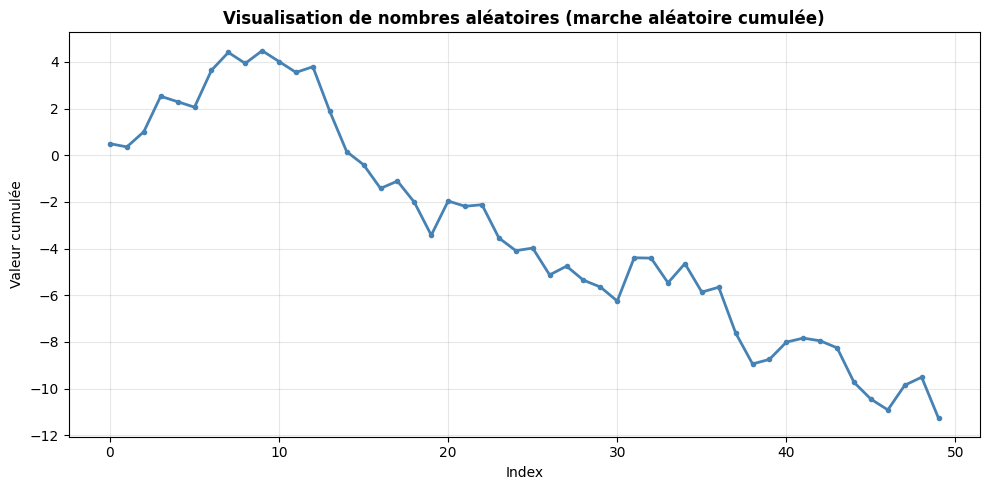

In [10]:
np.random.seed(42)

x = np.arange(0, 50)
y = np.random.randn(50).cumsum()  # marche aléatoire cumulée

plt.figure(figsize=(10, 5))
plt.plot(x, y, color='steelblue', linewidth=2, marker='o', markersize=3)
plt.title('Visualisation de nombres aléatoires (marche aléatoire cumulée)', fontweight='bold')
plt.xlabel('Index')
plt.ylabel('Valeur cumulée')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()